# Exploratory Data Analysis (EDA) — PdM_failures.csv

# 1 ) Introduction

## 1.1 Failure Analysis
Dataset

* Microsoft Azure Predictive Maintenance Dataset

Goal

* Analyze machine failure records to understand failure patterns, affected components, high-risk machines, and failure trends for predictive maintenance.

## 1.2 Dataset Feature Description
datetime
→ Timestamp when the failure occurred

machineID
→ Unique machine identifier

failure
→ Failed machine component

## 1.3 Business Objective

The objective of this analysis is to understand machine failure behavior and identify critical failure patterns. The insights obtained will support predictive maintenance planning, reduce downtime, and improve machine reliability.

# 2 ) Data Understanding

## 2.1 Library Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')

%matplotlib inline

* Required libraries have been successfully imported.
* Environment is ready for analysis and visualization.

## 2.2 Load Dataset

In [3]:
failures = pd.read_csv("PdM_failures.csv")

failures.head()

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


* Dataset loaded successfully.
* Each record represents a machine failure event.

## 2.3 Dataset Information

In [4]:
failures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   761 non-null    object
 1   machineID  761 non-null    int64 
 2   failure    761 non-null    object
dtypes: int64(1), object(2)
memory usage: 18.0+ KB


* Dataset contains machine failure history.
* Failure information is categorical.

## 2.4 Dataset Shape

In [5]:
print("Rows :", failures.shape[0])
print("Columns :", failures.shape[1])

Rows : 761
Columns : 3


* Dataset contains approximately 761 failure records.
* Small but highly important dataset.

# 3 ) Missing Value Analysis

## 3.1 Missing Values

In [6]:
failures.isnull().sum()

,0
datetime,0
machineID,0
failure,0


* No missing values detected.
* Dataset quality is high.

# 4 ) Duplicate Analysis

## 4.1 Duplicate Records

In [7]:
duplicates = failures.duplicated().sum()

print("Duplicates :", duplicates)

Duplicates : 0


* Duplicate records should be reviewed if present.

# 5 ) Failure Distribution Analysis

## 5.1 Failure Type Frequency

In [8]:
failures['failure'].value_counts()

,count
failure,
comp2,259
comp1,192
comp4,179
comp3,131


* Different components fail at different frequencies.

## 5.2 Failure Type Distribution (Bar Chart)

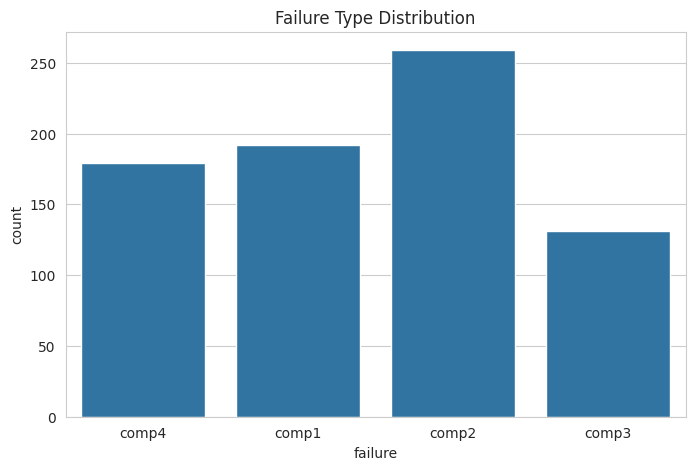

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='failure',
    data=failures
)

plt.title("Failure Type Distribution")

plt.show()

* Failure occurrences are not evenly distributed.

## 5.3 Failure Percentage Distribution (Pie Chart)

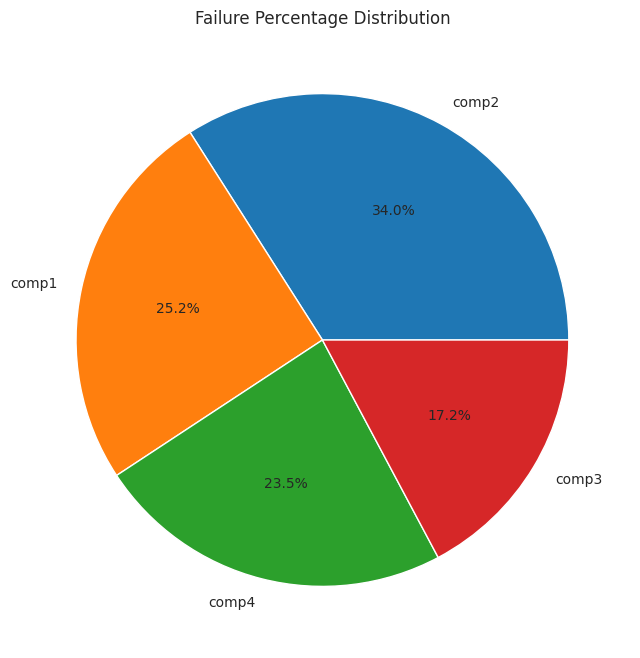

In [10]:
plt.figure(figsize=(8,8))

failures['failure'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title(
    "Failure Percentage Distribution"
)

plt.ylabel("")

plt.show()

* Failure contribution of each component is clearly visible.

# 6 ) Machine-wise Failure Analysis

## 6.1 Top 10 Machines with Highest Failures

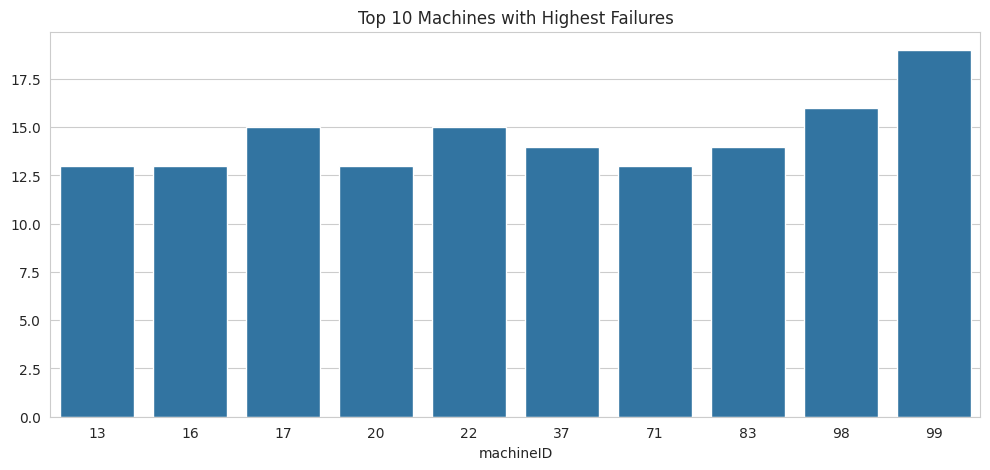

In [11]:
top_failures = (
    failures['machineID']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_failures.index,
    y=top_failures.values
)

plt.title(
    "Top 10 Machines with Highest Failures"
)

plt.show()

* Certain machines experience more failures.

## 6.2 Failure Count per Machine

In [12]:
failures.groupby(
    'machineID'
).size().sort_values(
    ascending=False
).head(20)

,0
machineID,
99,19
98,16
22,15
17,15
83,14
37,14
20,13
13,13
16,13


* Failure occurrences vary across machines.

# 7 ) Failure Timeline Analysis

## 7.1 Datetime Conversion

In [13]:
failures['datetime'] = pd.to_datetime(
    failures['datetime']
)

* Datetime conversion completed successfully.

## 7.2 Daily Failure Trend

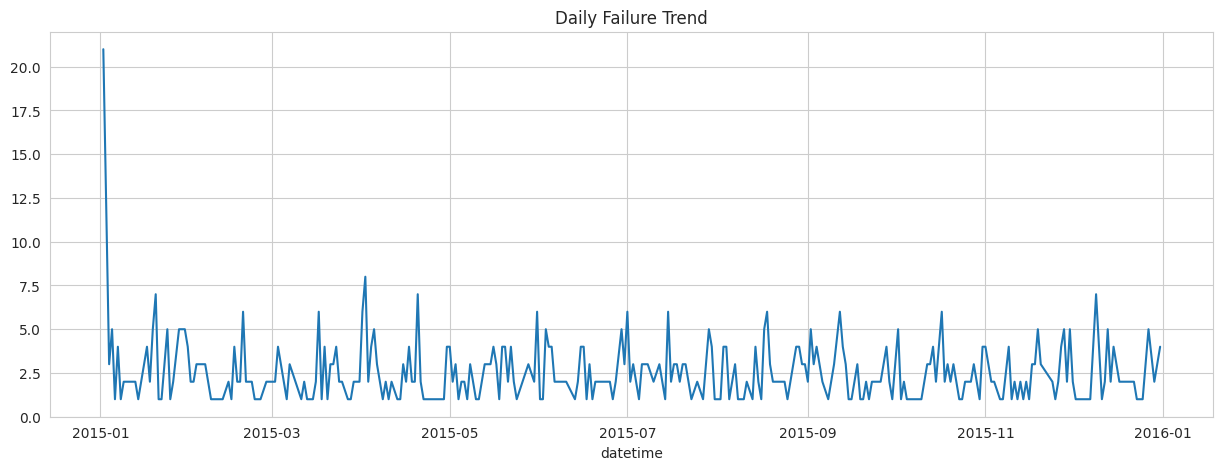

In [14]:
daily_failures = (
    failures.groupby(
        failures['datetime'].dt.date
    )
    .size()
)

plt.figure(figsize=(15,5))

daily_failures.plot()

plt.title(
    "Daily Failure Trend"
)

plt.show()

* Failure activity may indicate changing machine conditions.

## 7.3 Monthly Failure Trend

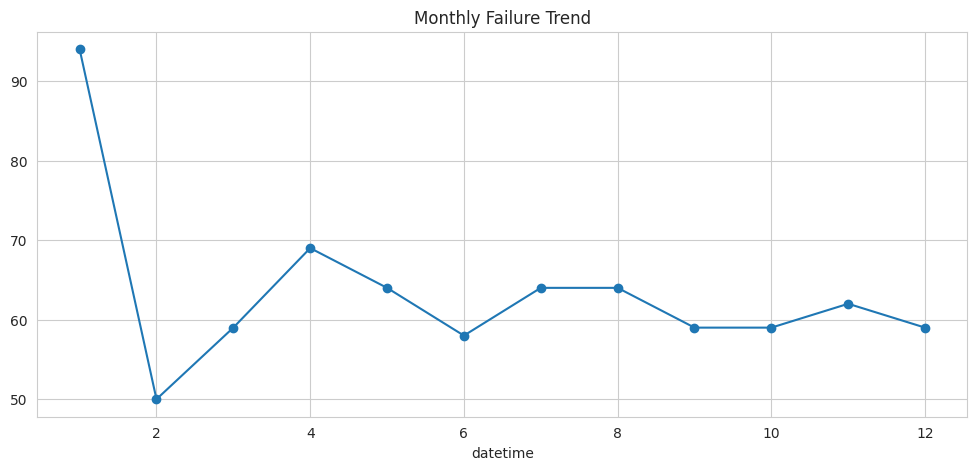

In [15]:
monthly_failures = (
    failures.groupby(
        failures['datetime'].dt.month
    )
    .size()
)

plt.figure(figsize=(12,5))

monthly_failures.plot(
    marker='o'
)

plt.title(
    "Monthly Failure Trend"
)

plt.show()

* Monthly variations in failures are visible.

# 8 ) Component-wise Failure Analysis

## 8.1 Component Failure Frequency

In [16]:
failures['failure'].value_counts()

,count
failure,
comp2,259
comp1,192
comp4,179
comp3,131


* Some components fail more often.

## 8.2 Component Failure Comparison

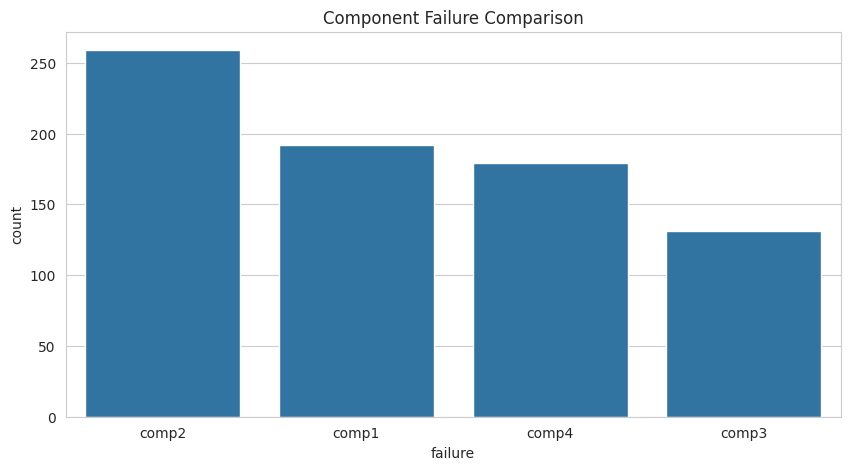

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='failure',
    data=failures,
    order=failures['failure'].value_counts().index
)

plt.title(
    "Component Failure Comparison"
)

plt.show()

* Component-wise failure comparison is clearly visible.

# 9 ) Failure Heatmap Analysis

## 9.1 Machine vs Failure Heatmap

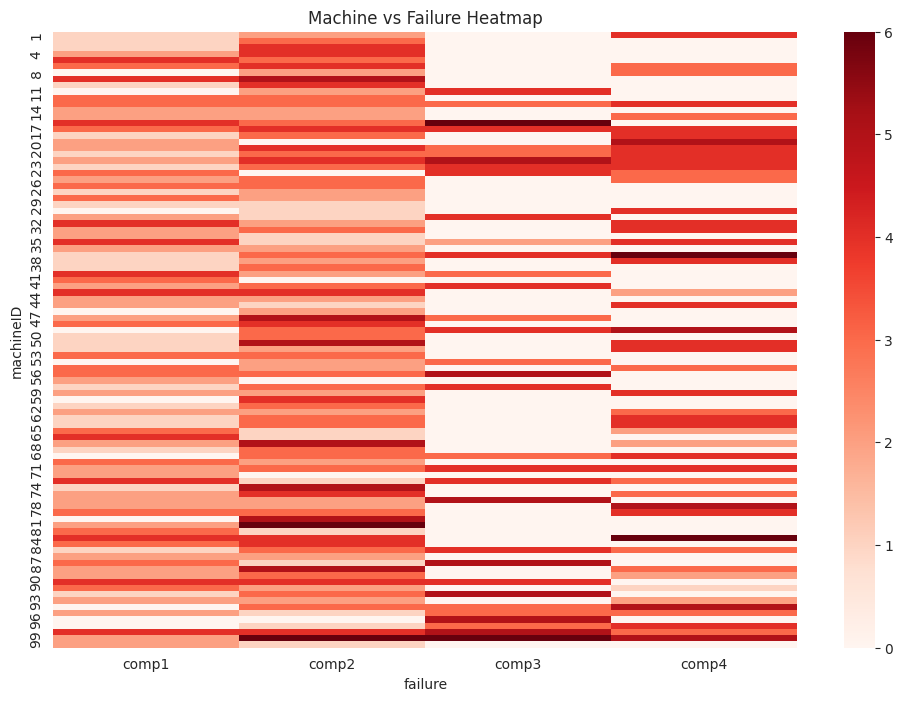

In [18]:
failure_heatmap = pd.crosstab(
    failures['machineID'],
    failures['failure']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    failure_heatmap,
    cmap='Reds'
)

plt.title(
    "Machine vs Failure Heatmap"
)

plt.show()

* Certain machines experience specific failure types more frequently

# 10 ) Failure Risk Analysis

## 10.1 Failure Risk Score

In [19]:
failure_count = (
    failures.groupby('machineID')
    .size()
)

failure_risk = (
    failure_count
    /
    failure_count.max()
) * 100

failure_risk.sort_values(
    ascending=False
).head(10)

,0
machineID,
99,100.000000
98,84.210526
22,78.947368
17,78.947368
83,73.684211
37,73.684211
20,68.421053
13,68.421053
16,68.421053


* Machines can be ranked by failure risk.

## 10.2 Top Risk Machines

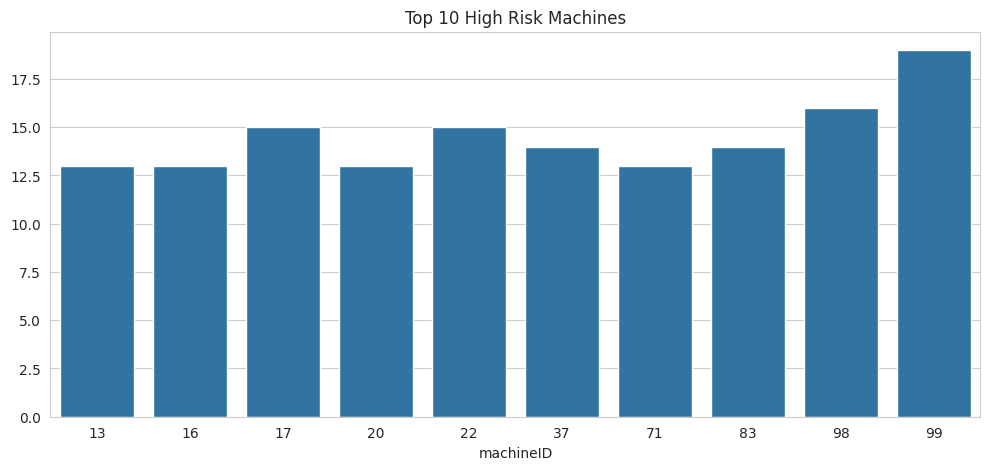

In [20]:
risk_machine = (

    failures['machineID']
    .value_counts()
    .head(10)

)

plt.figure(figsize=(12,5))

sns.barplot(
    x=risk_machine.index,
    y=risk_machine.values
)

plt.title(
    "Top 10 High Risk Machines"
)

plt.show()

# 11 ) Failure Pattern Analysis

## 11.1 Failure by Month

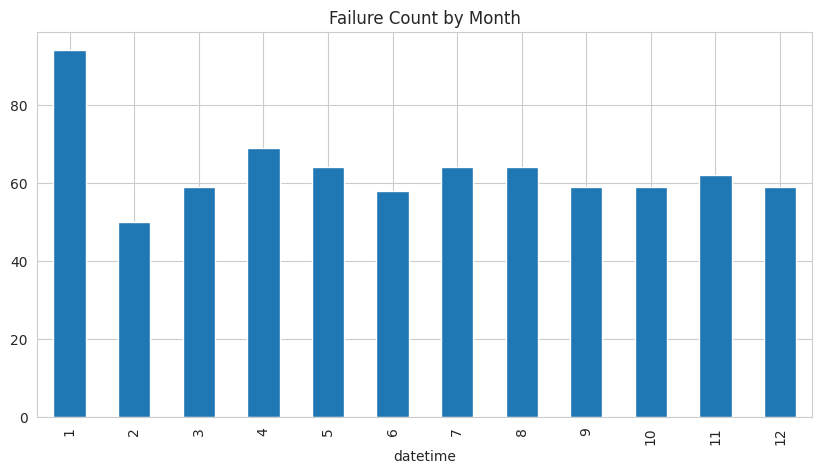

In [21]:
month_failure = (

    failures.groupby(
        failures['datetime'].dt.month
    )

    ['failure']

    .count()

)

month_failure.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Failure Count by Month"
)

plt.show()

* Failure frequency changes across months.

## 11.2 Monthly Component Failure Trend

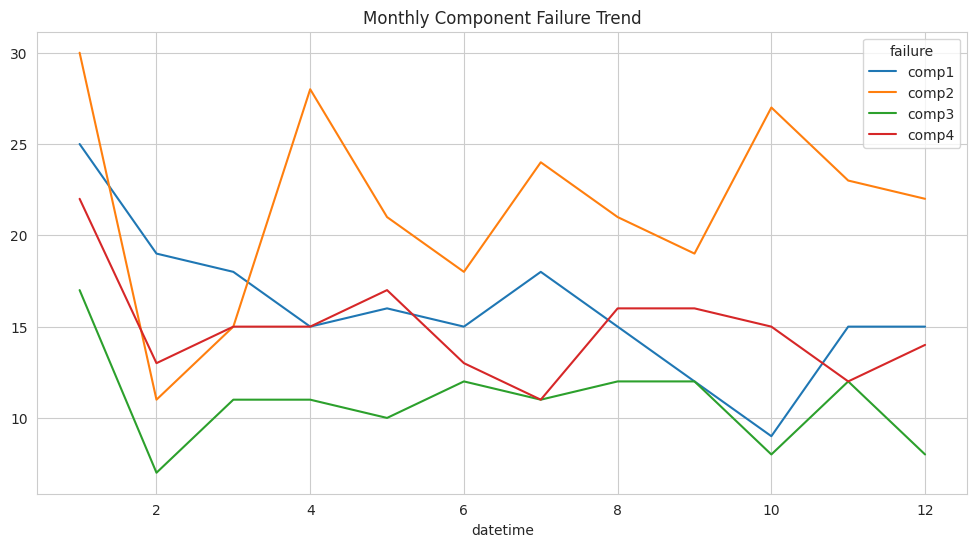

In [22]:
monthly_component = pd.crosstab(
    failures['datetime'].dt.month,
    failures['failure']
)

monthly_component.plot(
    figsize=(12,6)
)

plt.title(
    "Monthly Component Failure Trend"
)

plt.show()

* Different components show different failure patterns.